# Otoczka wypukła dla zbioru punktów w przestrzeni dwuwymiarowej 

### Import bibliotek

In [105]:
import numpy as np
import matplotlib.pyplot as plt

### Implementacja funkcji wizualizujących **(tymczasowe)**

In [106]:
def vis_set(points, aspect='equal'):
    plt.scatter(*zip(*points))
    plt.gca().set_aspect(aspect)
    plt.xlabel('x')
    plt.ylabel('y')
    plt.show()

### Implementacja funkcji pomocniczych

Wyznacznik macierzy 2x2

In [107]:
def mat_det_2x2(a, b, c):
    return (a[0]-c[0]) * (b[1]-c[1]) - (a[1]-c[1]) * (b[0]-c[0])

Funkcja zwracająca orientację

In [108]:
eps = 1e-12

def orient(a, b, c):
    det = mat_det_2x2(a, b, c)
    if det > eps:
        return 1
    elif det < -eps:
        return -1
    return 0

### Generowanie zbiorów testowych

In [109]:
def gen_a(a, b, n):
    points = []
    for _ in range(n):
        points.append((np.random.uniform(a, b), np.random.uniform(a, b)))
    return points

In [110]:
points_a = gen_a(-10, 10, 50)

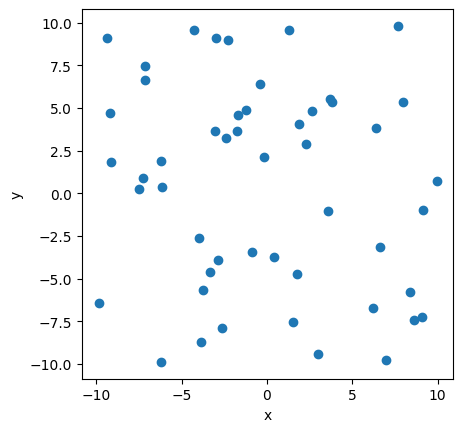

In [111]:
vis_set(points_a)

### Algorytm przyrostowy

In [112]:
def is_inside_hull(hull, point):
    a = 1
    b = len(hull)-1
    x = b//2
    while orient(hull[0], hull[a], point) == 1 and orient(hull[0], hull[b], point) == -1:
        if b == a + 1:
            break
        elif orient(hull[0], hull[a], point) == 1 and orient(hull[0], hull[x], point) == -1:
            b = x
            x = (a + b)//2
        else:
            a = x
            x = (a + b)//2
    if orient(hull[0], hull[a], point) == -1 or orient(hull[0], hull[b], point) == 1:
        return False
    if orient(hull[a], hull[b], point) == -1:
        return False
    return True
    

In [113]:
def incremental(points):
    n = len(points)
    hull = points[:3]
    hull.sort(key=lambda x: (x[1], x[0]))
    if orient(hull[0], hull[1], hull[2]) == -1:
        hull[1], hull[2] = hull[2], hull[1]
    for i in range(3, n):
        if not is_inside_hull(hull, points[i]):
            ...

In [114]:
incremental(points_a)